🚨 警告: 物体が破壊されました（スパゲッティ化）
破壊時の時間: 0.958 秒
破壊時のブラックホールからの距離: 597.8 km
破壊時の潮汐力 (G): 3170.8


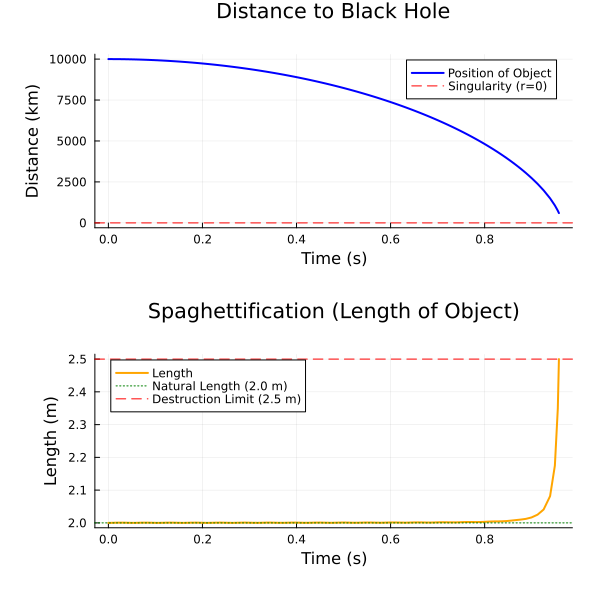

In [6]:
# 必要なパッケージ（未インストールの場合は Pkg.add("DifferentialEquations")）
using DifferentialEquations

# 1. 物理パラメータの定義
const G = 6.67430e-11 # 万有引力定数
const M = 1.989e30 * 10 # ブラックホールの質量（太陽質量の10倍）
const m = 70.0 # 物体の質量 (kg)
const x0 = 2.0 # 物体の初期の長さ/自然長 (m)
const k = 1.0e6 # 物体の結合力（バネ定数）
const L_max = 2.5 # 破壊限界の長さ (m) これを超えるとちぎれる

# 2. 微分方程式の定義
function tidal_forces!(du, u, p, t)
    # u[1]: BHからの距離 (r)
    # u[2]: 落下速度 (dr/dt)
    # u[3]: 物体の長さ (x)
    # u[4]: 伸びる速度 (dx/dt)
    
    r, v_r, x, v_x = u
    
    # 距離の計算（特異点r=0の回避）
    r = max(r, 1.0) 

    # BHへの落下（ニュートン力学の近似）
    du[1] = v_r
    du[2] = - (G * M) / r^2
    
    # 潮汐力とバネの力の綱引き
    F_tidal = (2 * G * M * m / r^3) * x
    F_spring = -k * (x - x0)
    
    # 物体の長さの変化
    du[3] = v_x
    du[4] = (F_tidal + F_spring) / m
end

# 3. 破壊イベント（スパゲッティ化）の検知
# 物体の長さ(u[3])が限界(L_max)を超えたらシミュレーションを停止
condition(u, t, integrator) = u[3] - L_max
affect!(integrator) = terminate!(integrator)
cb = ContinuousCallback(condition, affect!)

# 4. 初期条件と時間設定
r0 = 1.0e7 # 初期位置 (10,000 km)
v_r0 = 0.0 # 初期速度
u0 = [r0, v_r0, x0, 0.0]
tspan = (0.0, 10.0) # シミュレーション時間 (秒)

# 5. 問題の定義と求解
prob = ODEProblem(tidal_forces!, u0, tspan)
sol = solve(prob, Tsit5(), callback=cb)

# 6. 結果の出力
if sol.retcode == ReturnCode.Terminated
    println("🚨 警告: 物体が破壊されました（スパゲッティ化）")
    println("破壊時の時間: ", round(sol.t[end], digits=3), " 秒")
    println("破壊時のブラックホールからの距離: ", round(sol[1, end]/1000, digits=1), " km")
    println("破壊時の潮汐力 (G): ", round((2 * G * M * m / sol[1, end]^3 * sol[3, end]) / (m * 9.8), digits=1))
else
    println("✅ 物体は無事に（破壊されずに）シミュレーション時間を終えました。")
end

# 描画パッケージの読み込み（未インストールの場合は Pkg.add("Plots")）
using Plots

# グラフ用データの抽出
t_data = sol.t              # 時間
r_data = sol[1, :] ./ 1000  # BHからの距離 (kmに変換)
x_data = sol[3, :]          # 物体の長さ (m)

# 1. ブラックホールへの落下距離のグラフ
p1 = plot(t_data, r_data, 
    title = "Distance to Black Hole",
    xlabel = "Time (s)", 
    ylabel = "Distance (km)",
    label = "Position of Object",
    color = :blue,
    linewidth = 2,
    grid = true
)

# 落下限界（特異点）を破線で表示
hline!(p1, [0], color=:red, linestyle=:dash, label="Singularity (r=0)")

# 2. 物体の長さ（スパゲッティ化）のグラフ
p2 = plot(t_data, x_data, 
    title = "Spaghettification (Length of Object)",
    xlabel = "Time (s)", 
    ylabel = "Length (m)",
    label = "Length",
    color = :orange,
    linewidth = 2,
    legend = :topleft,
    grid = true
)

# 自然長(x0)と破壊限界(L_max)を破線で表示
hline!(p2, [x0], color=:green, linestyle=:dot, label="Natural Length ($x0 m)")
hline!(p2, [L_max], color=:red, linestyle=:dash, label="Destruction Limit ($L_max m)")

# 3. 2つのグラフを上下に並べて表示
plot(p1, p2, layout = (2, 1), size=(600, 600), margin=5Plots.mm)

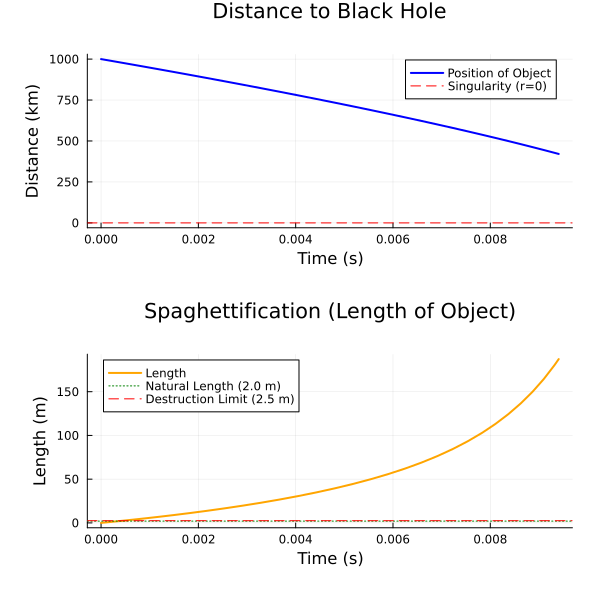

In [5]:
using DifferentialEquations, Plots

# 1. 物理定数 (国際単位系)
const G = 6.67430e-11   # 万有引力定数
const M = 1.989e30 * 10 # 太陽質量の10倍のブラックホール
const c = 2.99792458e8  # 光速 (m/s)
const rs = 2 * G * M / c^2 # シュワルツシルト半径 (約29.5 km)

const m = 70.0  # 物体の質量 (kg)
const x0 = 2.0  # 自然長 (m)
const k = 1.0e6 # バネ定数
const L_max = 2.5 # 破壊限界 (m)

# 2. 相対論的落下と測地線偏差（潮汐力）の微分方程式
function relativistic_tidal_forces!(du, u, p, tau)
    # u[1]: 距離 (r)
    # u[2]: 物体の長さ (x)
    # u[3]: 長さの変化速度 (dx/dτ)
    r, x, v_x = u
    r = max(r, 1.0) # 特異点回避
    
    # シュワルツシルト時空における自由落下速度（無限遠静止からの固有時微分）
    du[1] = -c * sqrt(rs / r)
    
    # 一般相対論における動径方向の潮汐力とバネの力の釣り合い
    F_tidal = m * (c^2 * rs / r^3) * x
    F_spring = -k * (x - x0)
    
    du[2] = v_x
    du[3] = (F_tidal + F_spring) / m
end

# 3. イベント検知（スパゲッティ化、または事象の地平面の通過）
# 条件1: スパゲッティ化（長さが L_max を超える）
cond_spaghetti(u, tau, integrator) = u[2] - L_max
affect_spaghetti!(integrator) = terminate!(integrator)

# 条件2: 事象の地平面を通過 (r が rs を下回る)
cond_horizon(u, tau, integrator) = u[1] - rs
affect_horizon!(integrator) = println("事象の地平面を通過！")

cb1 = ContinuousCallback(cond_spaghetti, affect_spaghetti!)
cb2 = ContinuousCallback(cond_horizon, affect_horizon!)
cbs = CallbackSet(cb1, cb2)

# 4. 初期条件と求解
r0 = 1000.0e3 # 初期位置 1,000 km
u0 = [r0, x0, 0.0]
tau_span = (0.0, 0.1) # 固有時で0.1秒

prob = ODEProblem(relativistic_tidal_forces!, u0, tau_span)
sol = solve(prob, Tsit5(), callback=cbs, reltol=1e-8, abstol=1e-8)

# --- (以下、前回と同様の Plots.jl による描画コード) ---
# 描画パッケージの読み込み（未インストールの場合は Pkg.add("Plots")）
using Plots

# グラフ用データの抽出
t_data = sol.t              # 時間
r_data = sol[1, :] ./ 1000  # BHからの距離 (kmに変換)
x_data = sol[3, :]          # 物体の長さ (m)

# 1. ブラックホールへの落下距離のグラフ
p1 = plot(t_data, r_data, 
    title = "Distance to Black Hole",
    xlabel = "Time (s)", 
    ylabel = "Distance (km)",
    label = "Position of Object",
    color = :blue,
    linewidth = 2,
    grid = true
)

# 落下限界（特異点）を破線で表示
hline!(p1, [0], color=:red, linestyle=:dash, label="Singularity (r=0)")

# 2. 物体の長さ（スパゲッティ化）のグラフ
p2 = plot(t_data, x_data, 
    title = "Spaghettification (Length of Object)",
    xlabel = "Time (s)", 
    ylabel = "Length (m)",
    label = "Length",
    color = :orange,
    linewidth = 2,
    legend = :topleft,
    grid = true
)

# 自然長(x0)と破壊限界(L_max)を破線で表示
hline!(p2, [x0], color=:green, linestyle=:dot, label="Natural Length ($x0 m)")
hline!(p2, [L_max], color=:red, linestyle=:dash, label="Destruction Limit ($L_max m)")

# 3. 2つのグラフを上下に並べて表示
plot(p1, p2, layout = (2, 1), size=(600, 600), margin=5Plots.mm)